## 01 — Bounding Box Intersection Test

We can compute a bounding box for any feature. Now we need the test: **does this feature's bounding box overlap the viewport?**

If the answer is no, the feature is off-screen and can be skipped entirely.

This notebook builds the intersection function and tests it against every edge case.

## The Key Insight — Think About Non-Overlap

It is easier to define when two rectangles **do not** intersect than when they do.

Two bounding boxes `A` and `B` do NOT intersect if any of these four conditions is true:

```
A is entirely to the LEFT   of B:  A.lon_max < B.lon_min
A is entirely to the RIGHT  of B:  A.lon_min > B.lon_max
A is entirely BELOW         B:     A.lat_max < B.lat_min
A is entirely ABOVE         B:     A.lat_min > B.lat_max
```

If **none** of those is true, the boxes overlap.

```
Separated left:      Separated right:     Separated below:     Separated above:
┌──┐                      ┌──┐            ┌────────┐           
│A │  ┌──┐          ┌──┐  │B │            │   B    │           ┌────────┐
└──┘  │B │          │A │  └──┘            └────────┘           │   B    │
      └──┘          └──┘                  ┌────────┐           └────────┘
                                          │   A    │           ┌────────┐
                                          └────────┘           │   A    │
                                                               └────────┘
```

## The Implementation

Both bounding boxes use the format `[lon_min, lat_min, lon_max, lat_max]`.

In [7]:
def bbox_intersects(bbox_a, bbox_b):
    """
    Return True if two bounding boxes overlap.
    Both boxes use [lon_min, lat_min, lon_max, lat_max] format.
    """
    a_lon_min, a_lat_min, a_lon_max, a_lat_max = bbox_a
    b_lon_min, b_lat_min, b_lon_max, b_lat_max = bbox_b

    # Check the four non-overlap conditions
    if a_lon_max < b_lon_min:  return False   # A entirely left of B
    if a_lon_min > b_lon_max:  return False   # A entirely right of B
    if a_lat_max < b_lat_min:  return False   # A entirely below B
    if a_lat_min > b_lat_max:  return False   # A entirely above B

    return True

## Testing Every Case

A function this small can be exhaustively tested. Let's define a fixed reference box and check every spatial relationship.

In [8]:
# Reference box: a viewport over Western Europe
viewport = [-10, 35, 30, 60]  # [lon_min, lat_min, lon_max, lat_max]

test_cases = [
    # (description, feature_bbox, expected_result)
    ("fully inside",               [ -5,  40,  10,  55],  True),
    ("fully outside — left",       [-50,  40, -20,  55],  False),
    ("fully outside — right",      [ 40,  40,  60,  55],  False),
    ("fully outside — below",      [ -5,  10,  10,  30],  False),
    ("fully outside — above",      [ -5,  65,  10,  75],  False),
    ("partial overlap — left edge",[-20,  40,   0,  55],  True),
    ("partial overlap — right edge",[ 20, 40,  40,  55],  True),
    ("partial overlap — bottom",   [ -5,  20,  10,  45],  True),
    ("partial overlap — top",      [ -5,  50,  10,  70],  True),
    ("feature contains viewport",  [-20,  20,  40,  70],  True),
    ("touching edge only",         [ 30,  40,  50,  55],  True),   # shares edge at lon=30
    ("touching corner only",       [ 30,  60,  50,  80],  True),   # touches at (30,60)
    ("diagonal — no overlap",      [ 35,  65,  50,  80],  False),
]

all_passed = True
for desc, feature_bbox, expected in test_cases:
    result = bbox_intersects(feature_bbox, viewport)
    status = "PASS" if result == expected else "FAIL"
    if result != expected:
        all_passed = False
    print(f"  {status}  {desc}")

print()
print("All tests passed" if all_passed else "SOME TESTS FAILED")

  PASS  fully inside
  PASS  fully outside — left
  PASS  fully outside — right
  PASS  fully outside — below
  PASS  fully outside — above
  PASS  partial overlap — left edge
  PASS  partial overlap — right edge
  PASS  partial overlap — bottom
  PASS  partial overlap — top
  PASS  feature contains viewport
  PASS  touching edge only
  PASS  touching corner only
  PASS  diagonal — no overlap

All tests passed


## Visualizing the Test Cases

Let's draw the viewport and a few of the test cases to make the geometry concrete.

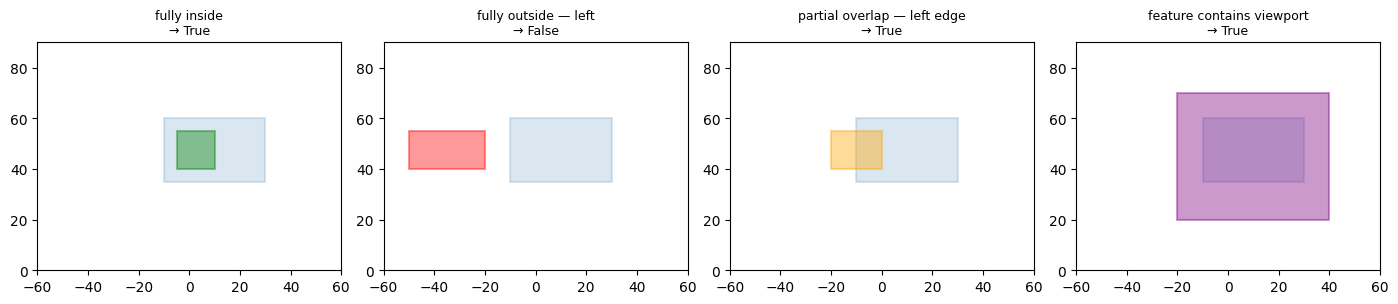

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_bbox(ax, bbox, color, label, alpha=0.3):
    lon_min, lat_min, lon_max, lat_max = bbox
    rect = patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5, edgecolor=color, facecolor=color, alpha=alpha, label=label
    )
    ax.add_patch(rect)

selected = [
    ("fully inside",                [-5, 40, 10, 55]),
    ("fully outside — left",        [-50, 40, -20, 55]),
    ("partial overlap — left edge", [-20, 40, 0, 55]),
    ("feature contains viewport",   [-20, 20, 40, 70]),
]

colors = ["green", "red", "orange", "purple"]

fig, axes = plt.subplots(1, len(selected), figsize=(14, 4))

for ax, (desc, fbox), color in zip(axes, selected, colors):
    draw_bbox(ax, viewport, "steelblue", "viewport", alpha=0.2)
    draw_bbox(ax, fbox, color, "feature", alpha=0.4)
    overlaps = bbox_intersects(fbox, viewport)
    ax.set_xlim(-60, 60)
    ax.set_ylim(0, 90)
    ax.set_title(f"{desc}\n→ {overlaps}", fontsize=9)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Combining with Feature Bbox

Now we have both pieces. A complete culling check for one feature looks like this:

In [10]:
def feature_bbox(feature):
    coords = feature["geometry"]["coordinates"]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return [min(lons), min(lats), max(lons), max(lats)]


def is_visible(feature, viewport_bbox):
    """Return True if the feature's bounding box overlaps the viewport."""
    return bbox_intersects(feature_bbox(feature), viewport_bbox)

## Exercise A

The current `bbox_intersects` function uses strict `<` and `>` comparisons — boxes that share only an edge (touching but not overlapping) return `True`.

Write a version `bbox_intersects_strict` that returns `False` for boxes that only touch at an edge or corner — they must have a non-zero overlap area to return `True`.

For a map renderer, which version is more appropriate? Why?

In [11]:
def bbox_intersects_strict(bbox_a, bbox_b):
    """Return True only if the two boxes overlap with positive area."""
    a_lon_min, a_lat_min, a_lon_max, a_lat_max = bbox_a
    b_lon_min, b_lat_min, b_lon_max, b_lat_max = bbox_b

    if a_lon_max <= b_lon_min: return False
    if a_lon_min >= b_lon_max: return False
    if a_lat_max <= b_lat_min: return False
    if a_lat_min >= b_lat_max: return False
    return True

edge_cases = [
    ('touching edge only', [30, 40, 50, 55]),
    ('touching corner only', [30, 60, 50, 80]),
    ('partial overlap — right edge', [20, 40, 40, 55]),
]

print(f"{'Case':<28} {'Loose':>8} {'Strict':>8}")
print('-' * 48)
for desc, candidate in edge_cases:
    loose = bbox_intersects(candidate, viewport)
    strict = bbox_intersects_strict(candidate, viewport)
    print(f"{desc:<28} {str(loose):>8} {str(strict):>8}")

print()
print('For rendering, the loose version is safer because it keeps edge-touching features that can still be visible on the map border.')


Case                            Loose   Strict
------------------------------------------------
touching edge only               True    False
touching corner only             True    False
partial overlap — right edge     True     True

For rendering, the loose version is safer because it keeps edge-touching features that can still be visible on the map border.


## Exercise B

Write a function `cull(features, viewport_bbox)` that takes a list of GeoJSON features and a viewport bounding box, and returns only the features that pass the intersection test.

Test it on the fine LOD file with the viewport set to Western Europe `[-10, 35, 30, 60]`. How many features survive?

In [12]:
import json
from pathlib import Path

with open(Path('../../data/lod/railroads_fine.geojson')) as f:
    fine = json.load(f)

def cull(features, viewport_bbox):
    return [feature for feature in features if is_visible(feature, viewport_bbox)]

viewport_bbox = [-10, 35, 30, 60]
visible = cull(fine['features'], viewport_bbox)

print(f'Viewport: {viewport_bbox}')
print(f"Visible features: {len(visible):,} / {len(fine['features']):,}")
print(f"Percent kept: {len(visible) / len(fine['features']) * 100:.1f}%")


Viewport: [-10, 35, 30, 60]
Visible features: 9,836 / 25,413
Percent kept: 38.7%


## Check Your Understanding

The bounding box test can produce **false positives** — features whose bounding box intersects the viewport but whose actual geometry does not.

Draw or describe a concrete example of this happening with a railroad segment. Then explain: is this a problem worth solving, or is it acceptable? What would "solving it" require?

A horseshoe-shaped or strongly diagonal railroad can wrap around the viewport so that its bbox overlaps the map window even though no actual track segment enters the window. That is usually acceptable because false positives only mean we render a few extra candidate features; eliminating them would require a second-stage geometry intersection test against the actual line, which is slower than the bbox filter.


## Next

In [02 — Viewport Culling](./02-Viewport_Culling.ipynb), we wire the intersection test into a live ipyleaflet map and measure how many features are eliminated at different zoom levels.